# Statistical Tests

Name: Wesley Stevick

Date: 

## Hypothesis Tests

#### Means
1. Identify 5 theologically salient lemmas from the top 20 lemmas (end of PS1) and compute per verse rates by book.

In [1]:
import pandas as pd
import os
from bs4 import BeautifulSoup
import re

# dictionary = pd.read_pickle(os.path.join("pickles", "dictionary.pickle"))
strong_soup = BeautifulSoup(open("data/strongs-dictionary.xhtml"), "xml")
dictionary = pd.DataFrame(columns=["id", "original", "definition", "kjv"]).set_index(
    "id"
)
for e in strong_soup("li", id=re.compile(r"nt:\d+")):
    kjv_e = e.find(class_="kjv_def")
    if kjv_e is None:
        kjv = ""
    else:
        kjv = kjv_e.text
    dictionary.loc[int(e["value"])] = [
        str(e.find("i").string).strip(),
        str(e.text).strip(),
        str(kjv).strip(),
    ]
nt = pd.read_pickle(os.path.join("pickles", "nt.pickle"))
zipf_20 = pd.read_pickle(os.path.join("pickles", "zipf-top20.pickle"))
morph = nt["parsed_rmac"].str.lower()
is_noun = morph.str.contains("noun")
is_verb = morph.str.contains("verb")
is_adj = morph.str.contains("adjective")
is_adv = morph.str.contains("adverb")
is_particle = morph.str.contains("particle")
interesting_numbers = (
    nt.loc[is_noun | is_verb | ~is_particle, "strong"].value_counts().index[:20]
)
"""
for n in interesting_numbers:
    print(n, dictionary.loc[n, 'kjv'], end='\n\n')
""";

   - 5547 Χριστός from χρίω; anointed, i.e. the Messiah, an epithet of Jesus: Christ.
   - 3708 ὁράω properly, to stare at (compare ὀπτάνομαι), i.e. (by implication) to discern clearly (physically or mentally); by extension, to attend to; by Hebraism, to experience; passively, to appear: behold, perceive, see, take heed.
   - 1510 εἰμί the first person singular present indicative; a prolonged form of a primary and defective verb; I exist (used only when emphatic): am, have been, X it is I, was. See also εἶ, εἴην, εἶναι, εἷς καθ’ εἷς, ἦν, ἔσομαι, ἐσμέν, ἐστέ, εἰμί0, εἰμί1, εἰμί2, εἰμί3.
   - 2424 Ἰησοῦς of Hebrew origin (יְהוֹשׁ֫וּעַ); Jesus (i.e. Jehoshua), the name of our Lord and two (three) other Israelites: Jesus.
   - 2316 θεός of uncertain affinity; a deity, especially (with ὁ) the supreme Divinity; figuratively, a magistrate; by Hebraism, very: X exceeding, God, god(-ly, -ward).

In [2]:
salient = [5547, 3708, 1510, 2424, 2316]

2. Are the per-verse rates between Synoptic Gospels and John the same for all 5 lemmas.

In [3]:
synoptic_ids = [40, 41, 42]
synoptics = nt.query("book in @synoptic_ids")
synoptic_nverses = len(synoptics.groupby(["book", "chapter", "verse"]))

john_id = 43
john = nt.query("book == @john_id")
john_nverses = len(john.groupby(["chapter", "verse"]))

In [4]:
from scipy.stats import ttest_ind
import numpy as np

for lemma in salient:
    synoptic_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in john.groupby(["chapter", "verse"])
        ]
    )
    result = ttest_ind(synoptic_counts, john_counts, equal_var=False)
    word = dictionary.loc[lemma, "original"]
    if result.pvalue >= 0.05:
        print(f"{word}: no difference")
    elif result.statistic > 0:
        print(f"{word} is more frequent in the synoptic gospels")
    else:
        print(f"{word} is more frequent in John")

Χριστός: no difference
ὁράω: no difference
εἰμί is more frequent in John
Ἰησοῦς is more frequent in John
θεός: no difference


3. What is the FWER if you were to do pairwise t-tests?

In [5]:
ntests = 5
alpha = 0.05
1 - (1 - alpha) ** ntests

0.22621906250000023

4. Do posthoc testing using the Bonferroni correction.

In [6]:
for lemma in salient:
    synoptic_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in john.groupby(["chapter", "verse"])
        ]
    )
    result = ttest_ind(synoptic_counts, john_counts, equal_var=False)
    word = dictionary.loc[lemma, "original"]
    if result.pvalue >= 0.05 / ntests:
        print(f"{word}: no difference")
    elif result.statistic > 0:
        print(f"{word} is more frequent in the synoptic gospels")
    else:
        print(f"{word} is more frequent in John")

Χριστός: no difference
ὁράω: no difference
εἰμί is more frequent in John
Ἰησοῦς is more frequent in John
θεός: no difference


5. Do posthoc testing using another correction method.

In [7]:
# holm-bonferroni (see https://chatgpt.com/share/68d7fffd-75e0-8002-8680-66402fee24bb)
tests = pd.DataFrame(columns=["lemma", "t", "p"])
for lemma in salient:
    synoptic_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_counts = np.array(
        [
            (verse["strong"] == lemma).sum()
            for _, verse in john.groupby(["chapter", "verse"])
        ]
    )
    result = ttest_ind(synoptic_counts, john_counts, equal_var=False)
    tests.loc[len(tests)] = [lemma, result.statistic, result.pvalue]
tests

tests.sort_values("p", inplace=True)
tests.reset_index(inplace=True)
reject = tests["p"] < 0.05 / (len(tests) - tests.index)
(dont_reject,) = np.where(~reject)
first_negative = dont_reject[0]
for lemma, t in tests[["lemma", "t"]].values[:first_negative]:
    word = dictionary.loc[lemma, "original"]
    if t > 0:
        print(f"{word} is more frequent in the synoptic gospels")
    else:
        print(f"{word} is more frequent in John")

Ἰησοῦς is more frequent in John
εἰμί is more frequent in John


6. Do posthoc testing using the Tukey method.

Tukey's method isn't useful for the tests I used bonferroni and holm-bonferroni for. Instead, I'm going to determine which terms have the highest per-verse rate in all the together, as that's a valid situation for Tukey.

In [8]:
from scipy.stats import tukey_hsd, f_oneway

all_gospel_ids = [40, 41, 42, 43]
gospels = nt.query("book in @all_gospel_ids")
samples = []  # one array of "term-per-verse" values for each lemma
for lemma in salient:
    samples.append(
        np.array(
            [
                (verse["strong"] == lemma).sum()
                for _, verse in gospels.groupby(["chapter", "book", "verse"])
            ]
        )
    )

if f_oneway(*samples).pvalue < 0.05:
    print("Total per-verse rates of terms differ")
    tukey_res = tukey_hsd(*samples)
    for i1, lemma1 in enumerate(salient):
        for i2 in range(i1 + 1, len(salient)):
            lemma2 = salient[i2]
            word1 = dictionary.loc[lemma1, "original"]
            word2 = dictionary.loc[lemma2, "original"]
            if tukey_res.pvalue[i1, i2] >= 0.05:
                print(word1, "has the same per-verse rate as", word2)

Total per-verse rates of terms differ


I had it print out all the rates that are the *same*, rather than all the rates that differ. Apparently each word has a different occurance than each other word, which makes sense. This isn't an interesting finding, I'm just showing off that I can do an ANOVA and Tukey

7. Are the results different betwen the three posthoc tests? Which results should you use and why?

Either holm-bonferroni (for it's increased statistical power while controlling FWER), or tukey, depending on the task.

### Proportion
8. Are the proportion of term presence vs term absence in verse the same between Synoptic Gospels and John for all 5 lemmas?

In [9]:
for lemma in salient:
    synoptic_presences = np.array(
        [
            lemma in verse["strong"]
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_presences = np.array(
        [lemma in verse["strong"] for _, verse in john.groupby(["chapter", "verse"])]
    )
    result = ttest_ind(synoptic_presences, john_presences, equal_var=False)
    word = dictionary.loc[lemma, "original"]
    if result.pvalue >= 0.05:
        print(f"{word}: no difference")
    elif result.statistic > 0:
        print(f"{word} is present in more verses in the synoptic gospels")
    else:
        print(f"{word} is present in more verses in John")

Χριστός: no difference
ὁράω: no difference
εἰμί: no difference
Ἰησοῦς: no difference
θεός: no difference


9. Correct these results for multiple tests using the Bonferroni correction.

In [10]:
for lemma in salient:
    synoptic_presences = np.array(
        [
            int(lemma in verse["strong"].values)
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_presences = np.array(
        [
            int(lemma in verse["strong"].values)
            for _, verse in john.groupby(["chapter", "verse"])
        ]
    )
    result = ttest_ind(synoptic_presences, john_presences, equal_var=False)
    word = dictionary.loc[lemma, "original"]
    if result.pvalue >= 0.05 / ntests:
        print(f"{word}: no difference")
    elif result.statistic > 0:
        print(f"{word} is present in more verses in the synoptic gospels")
    else:
        print(f"{word} is present in more verses in John")

Χριστός: no difference
ὁράω: no difference
εἰμί is present in more verses in John
Ἰησοῦς is present in more verses in John
θεός: no difference


10. Correct these results for multiple tests using the Benjamini-Hochberg correction.

In [11]:
results = pd.DataFrame(columns=["word", "t", "p"])

for lemma in salient:
    synoptic_presences = np.array(
        [
            int(lemma in verse["strong"].values)
            for _, verse in synoptics.groupby(["book", "chapter", "verse"])
        ]
    )
    john_presences = np.array(
        [
            int(lemma in verse["strong"].values)
            for _, verse in john.groupby(["chapter", "verse"])
        ]
    )
    result = ttest_ind(synoptic_presences, john_presences, equal_var=False)
    word = dictionary.loc[lemma, "original"]
    results.loc[len(results)] = [word, result.statistic, result.pvalue]

results.sort_values("p", inplace=True)
results.reset_index(inplace=True)
results["p_adj"] = results["p"] * (results.index + 1) / len(results)
(reject,) = np.where(results["p_adj"] < 0.05)
for word, t in results[["word", "t"]].values[: reject[-1] + 1]:
    if t > 0:
        print(f"{word} is present in more verses in the synoptic gospels")
    else:
        print(f"{word} is present in more verses in John")

Ἰησοῦς is present in more verses in John
εἰμί is present in more verses in John
ὁράω is present in more verses in the synoptic gospels


11. Why are the numbers from the Bonferroni correction different from the Benjamini-Hochberg correction? Which results should you use and why?

Benjamini-Hochberg has greater statistical power than Bonferroni, so is more sensitive to postive results. We'll use that instead.

### ANOVA
12. Do a term rate ANOVA comparison on a theologically salient lemma from the top 20 lemmas across the following groups: {Matthew and Mark, Luke and Acts, Johannine books, Pauline books, all other books}

###### lemma-change-here

In [62]:
#lemma = 5547 # Christ
#lemma = 26 # love
lemma = 5457 # light
groups = [
    ("Pauline", [45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58]),
    ("Matthew and Mark", [40, 41]),
    ("Luke and Acts", [42, 44]),
    # https://chatgpt.com/share/68d89ce9-bd5c-8002-8c6f-030e08b1e364
    ("Johannine", [43, 62, 63, 64, 66]),
]
samples = [
    (nt.query("book in @books")["strong"] == lemma).values.astype(int)
    for _, books in groups
]
if f_oneway(*samples).pvalue < 0.05:
    print("There is at least one difference!")
else:
    print("All the same!")

There is at least one difference!


13. Perform a Post-hoc Tukey HSD to see which pairs differ

In [63]:
tukey_res = tukey_hsd(*samples)
for i1 in range(len(groups)):
    for i2 in range(i1 + 1, len(groups)):
        print(groups[i1][0], "vs.", groups[i2][0], end=" ")
        if tukey_res.pvalue[i1, i2] < 0.05:
            greater = groups[i1 if tukey_res.statistic[i1, i2] > 0 else i2][0]
            print(f"differ (higher occurance in {greater})")
        else:
            print("do not differ")

Pauline vs. Matthew and Mark do not differ
Pauline vs. Luke and Acts do not differ
Pauline vs. Johannine differ (higher occurance in Johannine)
Matthew and Mark vs. Luke and Acts do not differ
Matthew and Mark vs. Johannine differ (higher occurance in Johannine)
Luke and Acts vs. Johannine differ (higher occurance in Johannine)


Paul talks more about Christ than anybody else.

Also Paul and John talk more about love, and Paul talks more about love than John.

John talks more about light than anyone else, which I predicted.

# Side Quest A

## Power Analysis

14. Conduct a power analysis for the question in #7 to determine how many verses are needed to detect the specified effect.
15. Simulate the answer.
    <ol type="a">
    <li>Simulate n verses with the proportions found in #8 for Synoptic Gospels and John. Do a test to see if significantly different and save this result.</li>
    <li>Repeat step a many times.</li>
    <li>Calculate power: power = (number of significant findings) / (total simulations)</li>
    <li>Repeat steps a-c for a different n.</li>
    <li>Plot power as a function of number of verses.</li>
    <li>At what number of verses is the power at least 80%? i.e. This is the number of verses you need per text to have an 80% chance of detecting the effect if it's really there.</li>
    </ol>

# Side Quest B
## Sliding Windows Stretch
16. Repeat ANOVA and Chi-square sections on the same three theological terms, but instead of using verse boundaries, use sliding windows (+/- n tokens)
17. How do results of verse boundaries compare to using sliding windows?

# Side Quest C
### Chi-square Test
18. Build a 2xk contingency table for collocation: presence of target term vs top-k companion terms within verse.

In [64]:
# https://chatgpt.com/share/68d8af20-9f10-8002-bef3-27abf6be3945
# https://chatgpt.com/share/68d8b177-a610-8002-9464-06e7c9737efc
# re-using lemma from 12
k = 20
verses_have_target = nt.groupby(["book", "chapter", "verse"]).filter(
    lambda verse: lemma in verse["strong"].values
)
in_verse_duplicates = verses_have_target.groupby(["book", "chapter", "verse"])[
    "strong"
].transform(lambda verse: verse.duplicated())
neighbors = verses_have_target.loc[~in_verse_duplicates]
neighbors_morph = neighbors["parsed_rmac"].str.lower()
neighbors = neighbors.loc[
    (neighbors["strong"] != lemma)
    & (neighbors_morph.str.contains("verb") | neighbors_morph.str.contains("noun")),
    'strong'
]
companion_counts = neighbors.value_counts()
top_k_companions = pd.Series(companion_counts.index[:k].values)
for strong in top_k_companions:
    print(*dictionary.loc[strong, ["original", "kjv"]], sep=' - ')

εἰμί - am, have been, X it is I, was
αὐτός - her, it(-self), one, the other, (mine) own, said, (self-), the) same, ((him-, my-, thy-)self, (your-)selves, she, that, their(-s), them(-selves), there(-at, - by, -in, -into, -of, -on, -with), they, (these) things, this (man), those, together, very, which
σκότος - darkness
ὑμεῖς - ye (yourselves), you
σκοτία - dark(-ness)
λέγω - ask, bid, boast, call, describe, give out, name, put forth, say(-ing, on), shew, speak, tell, utter
ὅς - one, (an-, the) other, some, that, what, which, who(-m, -se), etc
κόσμος - adorning, world
οὗτος - he (it was that), hereof, it, she, such as, the same, these, they, this (man, same, woman), which, who
ἔρχομαι - accompany, appear, bring, come, enter, fall out, go, grow, X light, X next, pass, resort, be set
ἐγώ - I, me
περιπατέω - go, be occupied with, walk (about)
γίνομαι - arise, be assembled, be(-come, -fall, -have self), be brought (to pass), (be) come (to pass), continue, be divided, draw, be ended, fall, be 

In [65]:
table = np.zeros(shape=(2, k), dtype=int)
# row 0 is target not present, row 1 is target present
# column i is the term i
for target_present in [0, 1]:
    search_within = nt.groupby(["book", "chapter", "verse"]).filter(
        lambda verse: int(lemma in verse["strong"].values) == target_present
    )
    for i, companion in enumerate(top_k_companions):
        table[target_present, i] += (
            search_within.groupby(["book", "chapter", "verse"])["strong"].apply(
                lambda g: companion in g.values
            )
        ).sum()

19. Run Chi-square tests of independence; compute standardized residuals to find surprising co-occurrences

In [66]:
# https://chatgpt.com/share/68dc8c62-e38c-8002-a4fb-9de8aa431262
from scipy.stats import norm

row_sums = table.sum(axis=1)
col_sums = table.sum(axis=0)
total = table.sum()

# only computing chi-squared for row corresponding to "target term present"
expected = col_sums * row_sums[1] / total
adjusted_residuals = (table[1, :] - expected) / np.sqrt(
    expected * (1 - row_sums[1] / total) * (1 - col_sums / total)
)

term_residuals = pd.DataFrame(columns=["term", "residual"])
term_residuals["term"] = top_k_companions
term_residuals["residual"] = adjusted_residuals
term_residuals["greek"] = dictionary.loc[term_residuals["term"], "original"].values
term_residuals["kjv"] = dictionary.loc[term_residuals["term"], "kjv"].values

ps = 2 * (1 - norm.cdf(abs(adjusted_residuals)))
sort_ix = np.argsort(ps)
reject = ps[sort_ix] < alpha / (k - np.arange(k))
(fail_reject_pos,) = np.where(~reject)
relevent_ix = sort_ix[: fail_reject_pos[0]]

relevent_term_residuals = term_residuals.iloc[relevent_ix]
relevent_term_residuals.sort_values("residual", ascending=False, inplace=True)
pos_corr = relevent_term_residuals[relevent_term_residuals["residual"] > 0]
print("positively correlated terms")
pos_corr

positively correlated terms


/tmp/ipykernel_12607/156103355.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevent_term_residuals.sort_values("residual", ascending=False, inplace=True)


,term,residual,greek,kjv
4,4653,25.538408,σκοτία,dark(-ness)
2,4655,21.287062,σκότος,darkness
11,4043,6.545720,περιπατέω,"go, be occupied with, walk (about)"
7,2889,4.493089,κόσμος,"adorning, world"
13,1484,3.653164,ἔθνος,"Gentile, heathen, nation, people"


For term 5547 (Christ):
I actually find it kind of funny how quintiscentially Christiany all of these are. I feel like I spent two hours doing advanced statistics for my model to put out "Jesus Bible Pray."

For term 26 (agape):
Agape and faith are highly correlated, which is interesting. Otherwise not too surprising (we're supposed to love each other and Christ, love endures, etc.)

For light: I see "light and darkness", I see "go be the light", I see "light of the world", and I see "be a light to the gentiles". This actually makes a lot of sense.

In [67]:
relevent_term_residuals.sort_values("residual", inplace=True)
neg_corr = relevent_term_residuals[relevent_term_residuals["residual"] < 0]
print("negatively correlated term")
neg_corr

negatively correlated term


/tmp/ipykernel_12607/99892724.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  relevent_term_residuals.sort_values("residual", inplace=True)


,term,residual,greek,kjv


Inverse correlations with "Christ" are "self", "say", "he", "you (informal)", "come together", and "am". These make less obvious sense.

Inverse correlations between Agape and "self" and "me". Apparently you're not supposed to love yourself?

No notable inverse correlations with light.

20. Visualize a heatmap of residuals

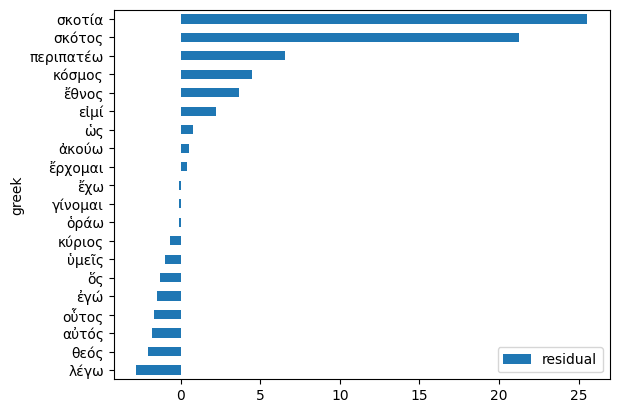

In [68]:
term_residuals.sort_values("residual", inplace=True)
term_residuals.plot.barh(y="residual", x="greek");

21. Explain results

See under residuals above

22. Repeat the ANOVA and Chi-square test sections for 2 other terms.

Did with Christ, Agape, and Light. Click [here](#lemma-change-here) to play with the lemma

# AI use

- https://chatgpt.com/share/68dc8c62-e38c-8002-a4fb-9de8aa431262
- https://chatgpt.com/share/68d8b177-a610-8002-9464-06e7c9737efc
- https://chatgpt.com/share/68d8af20-9f10-8002-bef3-27abf6be3945
- https://chatgpt.com/share/68dc8c94-a734-8002-88e0-d03554a2d31b
- https://chatgpt.com/share/68d89ce9-bd5c-8002-8c6f-030e08b1e364
- https://chatgpt.com/share/68d7fffd-75e0-8002-8680-66402fee24bb